In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
texas = pd.read_csv("Texas.csv")
texas.head()


,EVENT_ID,CZ_NAME_STR,BEGIN_LOCATION,BEGIN_DATE,BEGIN_TIME,EVENT_TYPE,MAGNITUDE,TOR_F_SCALE,DEATHS_DIRECT,INJURIES_DIRECT,...,END_LOCATION,END_DATE,END_TIME,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,EVENT_NARRATIVE,EPISODE_NARRATIVE,ABSOLUTE_ROWNUMBER
0,1267509,SAN SABA CO.,CHEROKEE,05/22/2025,2355,Heavy Rain,,,0,0,...,CHEROKEE,05/22/2025,2355,30.98,-98.64,30.98,-98.64,An LCRA automated rain gauge reported 5.22 inc...,The combination of surface instability and an ...,1
1,1267507,SAN SABA CO.,SAN SABA,05/22/2025,2325,Heavy Rain,,,0,0,...,SAN SABA,05/22/2025,2325,31.11,-98.72,31.11,-98.72,An LCRA automated rain gauge reported 5.66 inc...,The combination of surface instability and an ...,2
2,1267508,BROWN CO.,BLANKET,05/22/2025,2200,Heavy Rain,,,0,0,...,BLANKET,05/22/2025,2200,31.77,-98.79,31.77,-98.79,An LCRA automated rain gauge reported 5.01 inc...,The combination of surface instability and an ...,3
3,1247382,NUECES CO.,PETRONILA,05/08/2025,2105,Thunderstorm Wind,91.00,,0,0,...,PETRONILA,05/08/2025,2105,27.6802,-97.6416,27.6802,-97.6416,Mobile home blown off foundation into the stre...,A cluster of storms in La Salle County progres...,4
4,1249166,NUECES CO.,PETRONILA,05/08/2025,2105,Thunderstorm Wind,91.00,,0,0,...,PETRONILA,05/08/2025,2105,27.64,-97.63,27.64,-97.63,Several power poles snapped near the base.,A cluster of storms in La Salle County progres...,5


In [20]:
texas.info

<bound method DataFrame.info of      EVENT_ID                         CZ_NAME_STR BEGIN_LOCATION  BEGIN_DATE  \
0     1267509                        SAN SABA CO.       CHEROKEE  05/22/2025   
1     1267507                        SAN SABA CO.       SAN SABA  05/22/2025   
2     1267508                           BROWN CO.        BLANKET  05/22/2025   
3     1247382                          NUECES CO.      PETRONILA  05/08/2025   
4     1249166                          NUECES CO.      PETRONILA  05/08/2025   
..        ...                                 ...            ...         ...   
99    1224912                      BRISCOE (ZONE)                 01/09/2025   
100   1224911                      SWISHER (ZONE)                 01/09/2025   
101   1224903                       CASTRO (ZONE)                 01/09/2025   
102   1224902                       PARMER (ZONE)                 01/09/2025   
103   1235768  COASTAL SAN PATRICIO COUNTY (ZONE)                 01/02/2025   

     BE

In [21]:
texas.describe

<bound method NDFrame.describe of      EVENT_ID                         CZ_NAME_STR BEGIN_LOCATION  BEGIN_DATE  \
0     1267509                        SAN SABA CO.       CHEROKEE  05/22/2025   
1     1267507                        SAN SABA CO.       SAN SABA  05/22/2025   
2     1267508                           BROWN CO.        BLANKET  05/22/2025   
3     1247382                          NUECES CO.      PETRONILA  05/08/2025   
4     1249166                          NUECES CO.      PETRONILA  05/08/2025   
..        ...                                 ...            ...         ...   
99    1224912                      BRISCOE (ZONE)                 01/09/2025   
100   1224911                      SWISHER (ZONE)                 01/09/2025   
101   1224903                       CASTRO (ZONE)                 01/09/2025   
102   1224902                       PARMER (ZONE)                 01/09/2025   
103   1235768  COASTAL SAN PATRICIO COUNTY (ZONE)                 01/02/2025   

     

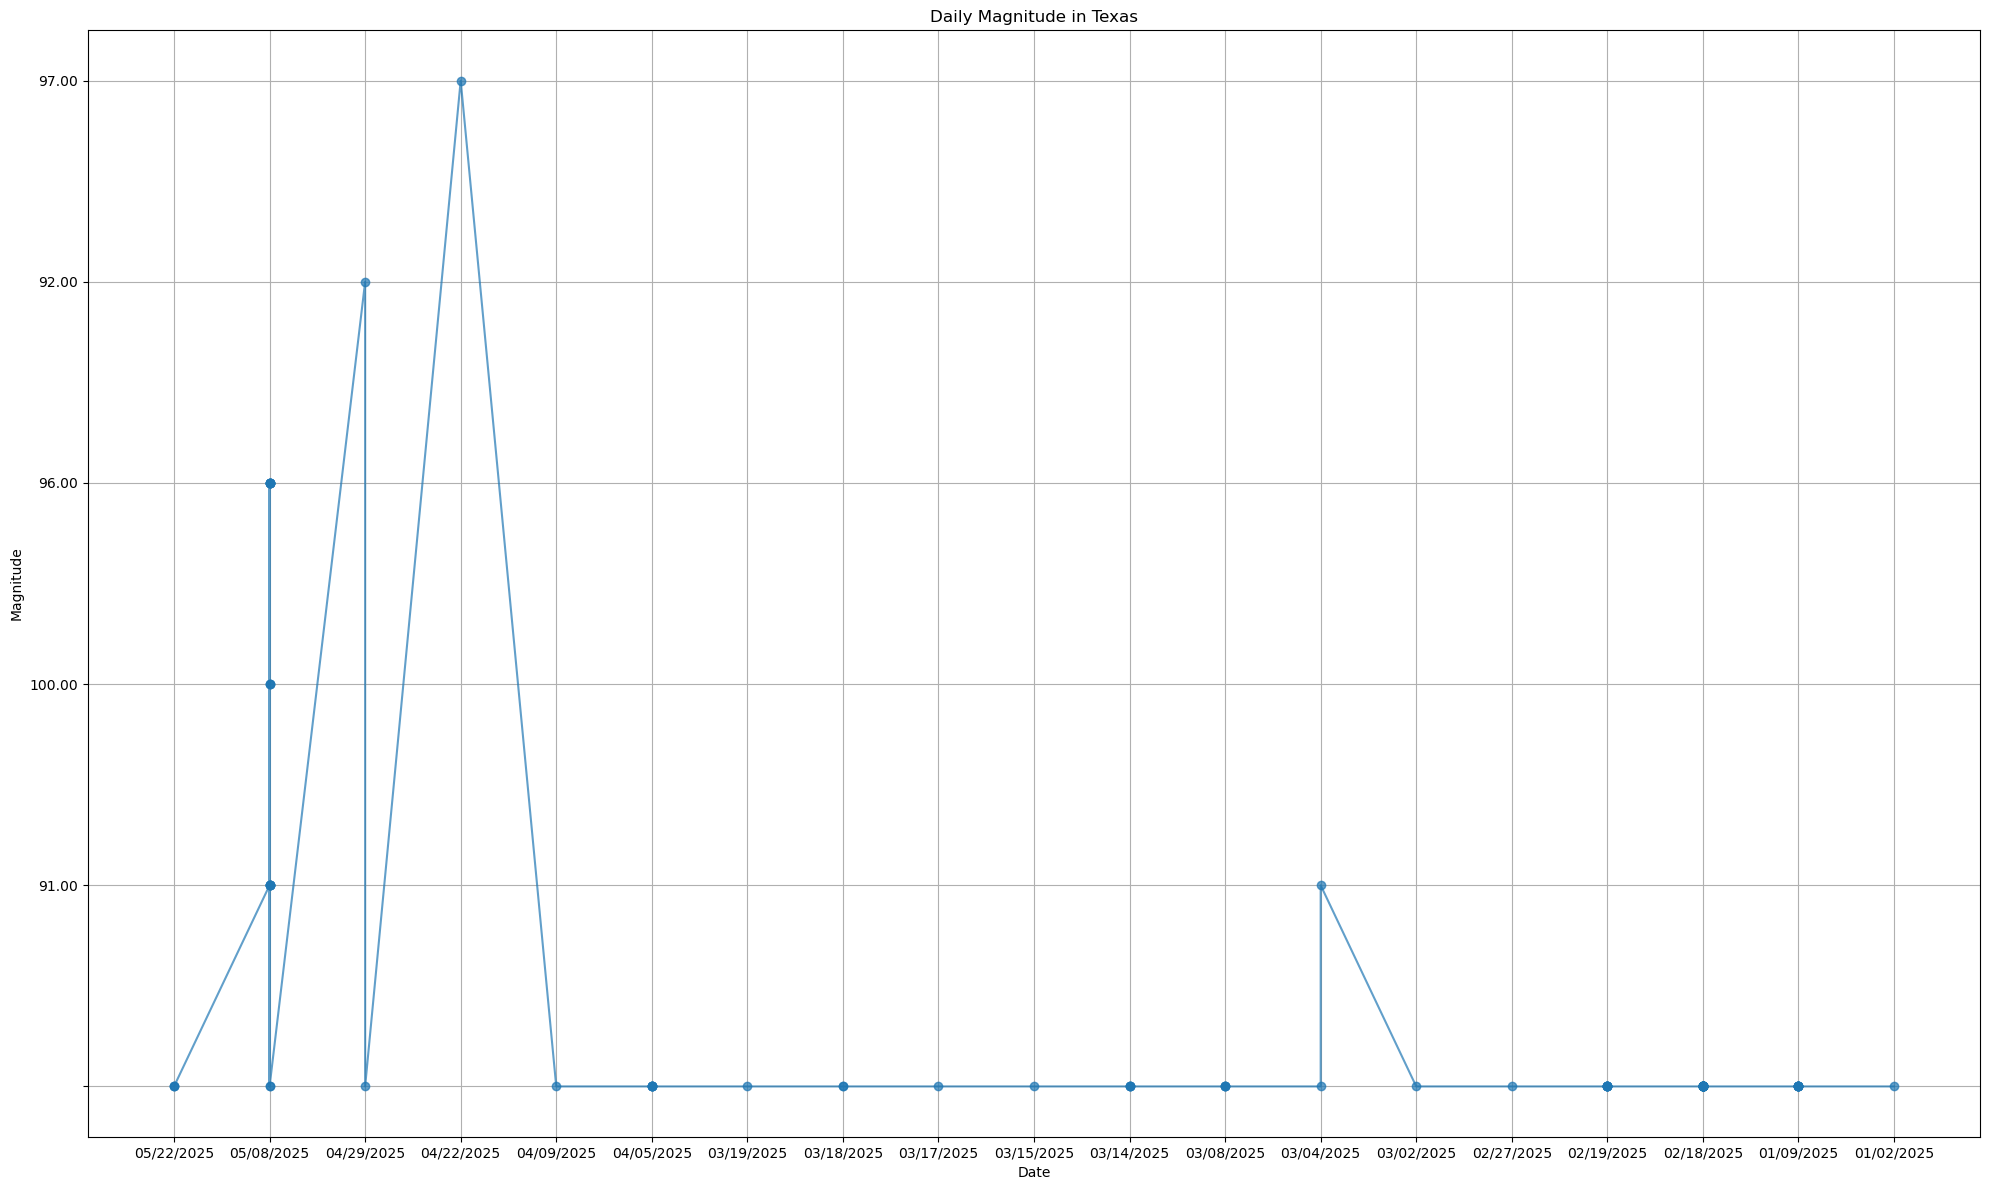

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 12))
plt.plot(texas['BEGIN_DATE'], texas['MAGNITUDE'], marker='o', linestyle='-', alpha=0.7)
plt.title('Daily Magnitude in Texas')
plt.xlabel('Date')
plt.ylabel('Magnitude')
plt.grid(True)
plt.tight_layout()
plt.show()

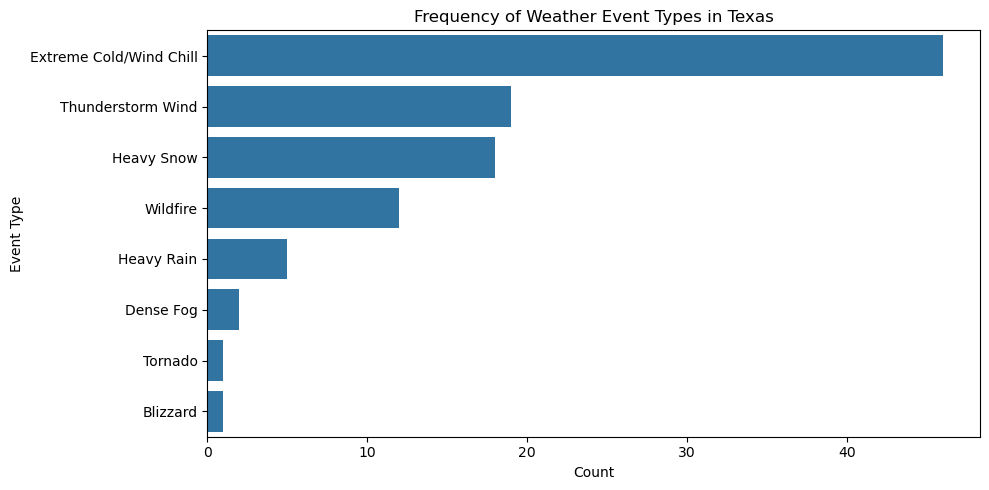

In [23]:
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.countplot(y='EVENT_TYPE', data=texas, order=texas['EVENT_TYPE'].value_counts().index)
plt.title('Frequency of Weather Event Types in Texas')
plt.xlabel('Count')
plt.ylabel('Event Type')
plt.tight_layout()
plt.show()

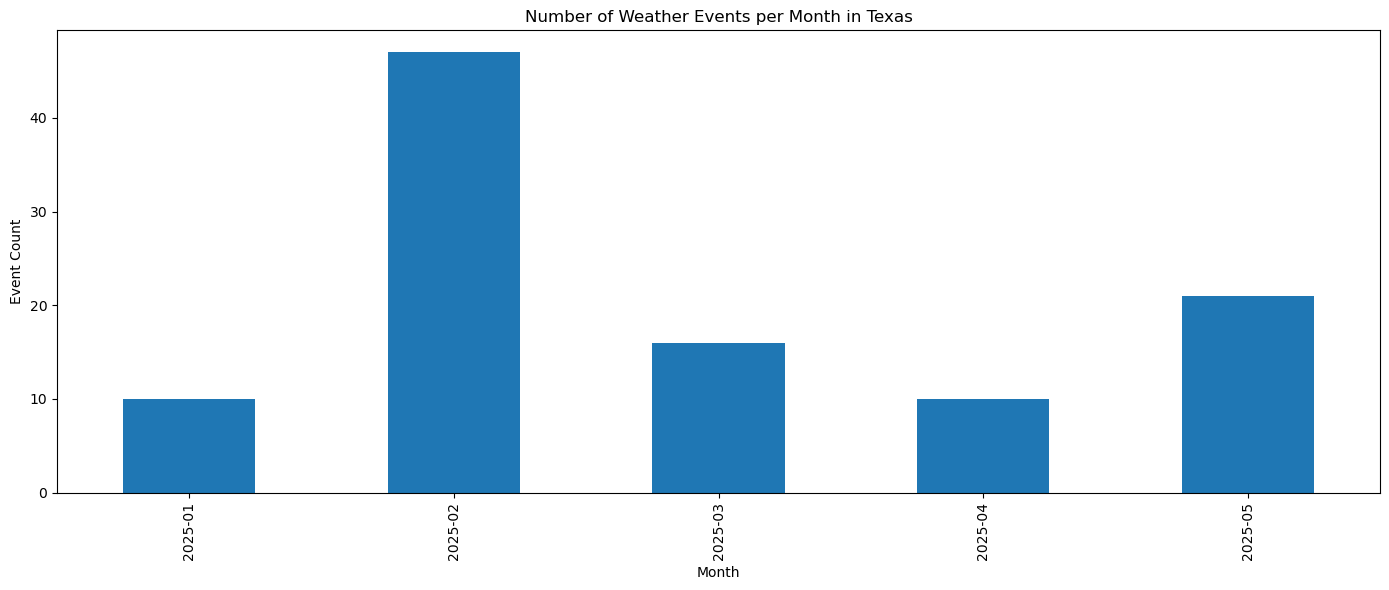

In [28]:
# Group by month and count events
texas['BEGIN_DATE'] = pd.to_datetime(texas['BEGIN_DATE'])
texas['Month'] = texas['BEGIN_DATE'].dt.to_period('M')
monthly_counts = texas.groupby('Month').size()

plt.figure(figsize=(14,6))
monthly_counts.plot(kind='bar')
plt.title('Number of Weather Events per Month in Texas')
plt.xlabel('Month')
plt.ylabel('Event Count')
plt.tight_layout()
plt.show()

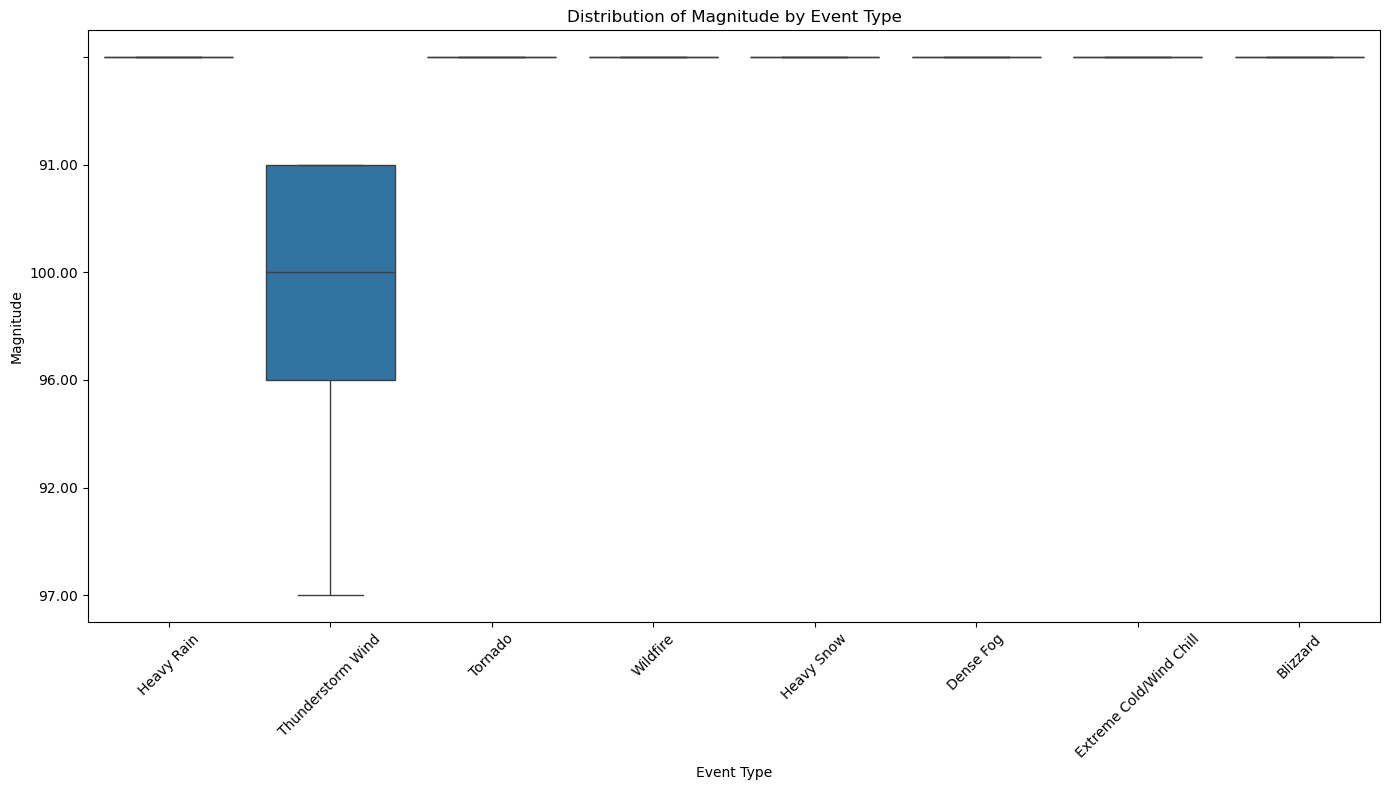

In [29]:
plt.figure(figsize=(14,8))
sns.boxplot(x='EVENT_TYPE', y='MAGNITUDE', data=texas)
plt.title('Distribution of Magnitude by Event Type')
plt.xlabel('Event Type')
plt.ylabel('Magnitude')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

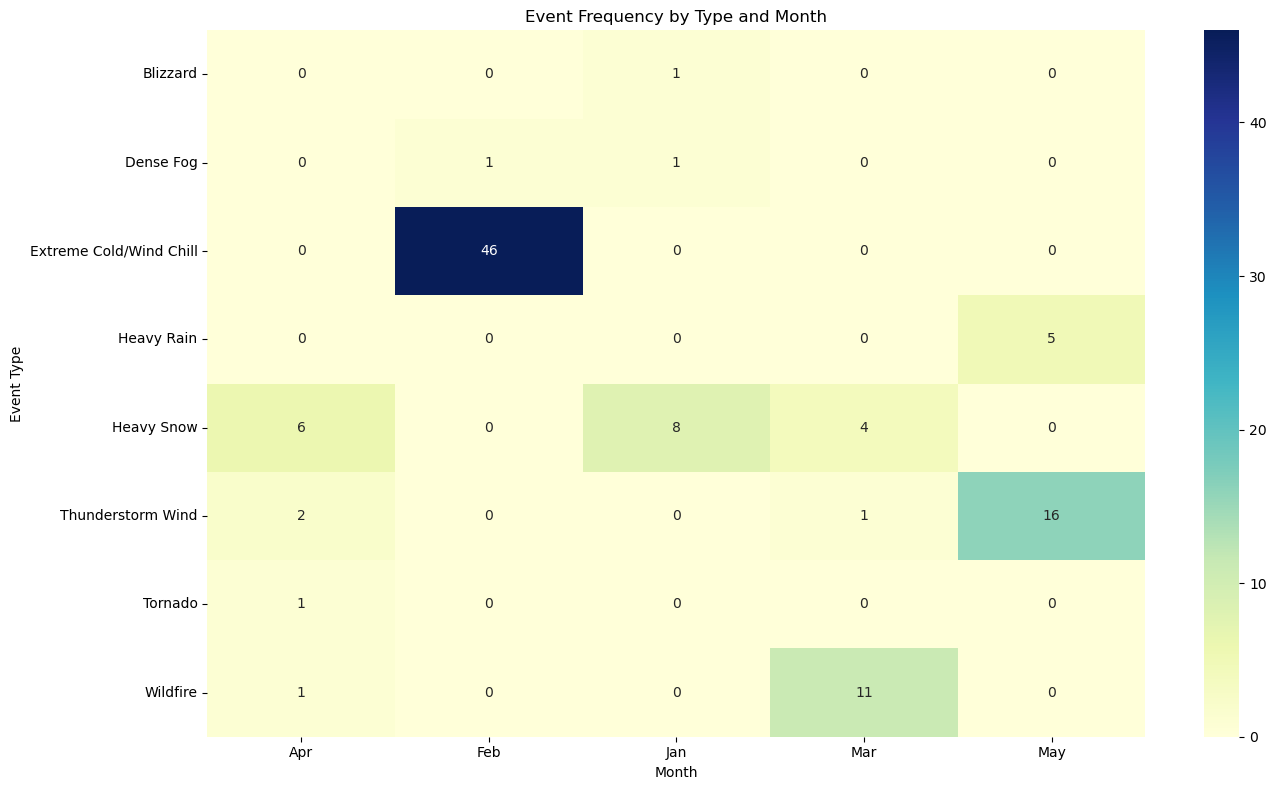

In [30]:
event_month = texas.copy()
event_month['Month'] = event_month['BEGIN_DATE'].dt.strftime('%b')
pivot = pd.pivot_table(event_month, index='EVENT_TYPE', columns='Month', values='MAGNITUDE', aggfunc='count', fill_value=0)
plt.figure(figsize=(14,8))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Event Frequency by Type and Month')
plt.xlabel('Month')
plt.ylabel('Event Type')
plt.tight_layout()
plt.show()

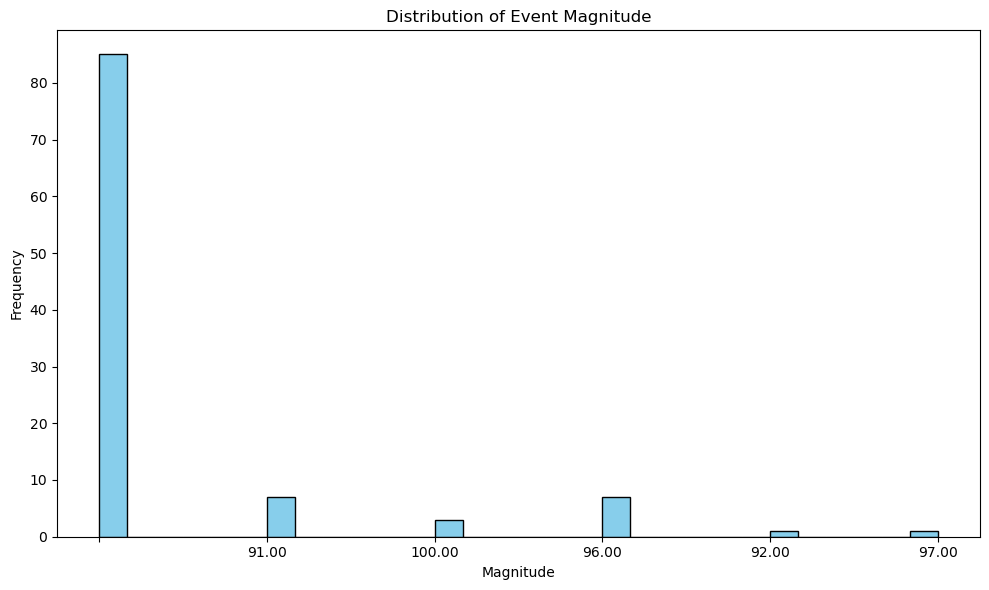

In [31]:
plt.figure(figsize=(10,6))
plt.hist(texas['MAGNITUDE'].dropna(), bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Event Magnitude')
plt.xlabel('Magnitude')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

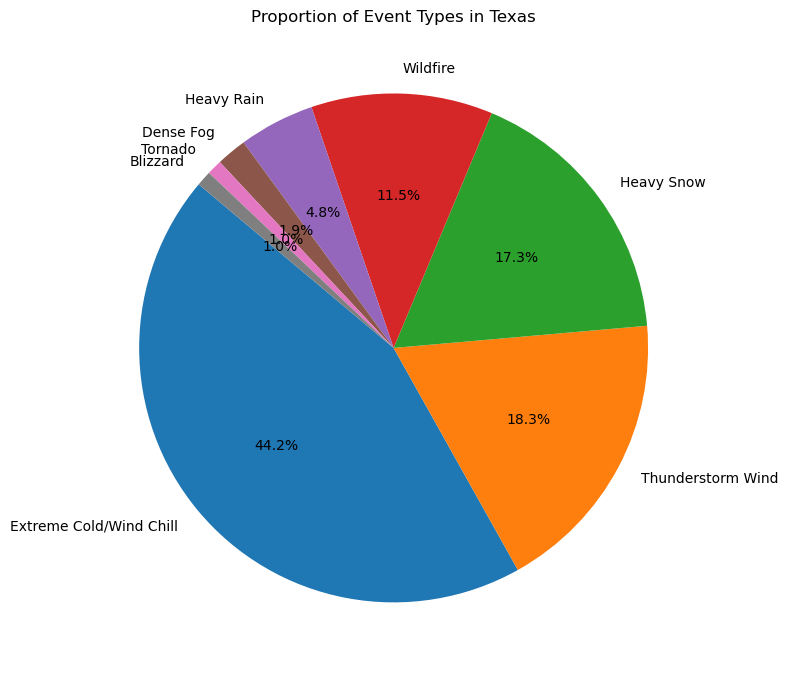

In [32]:
event_counts = texas['EVENT_TYPE'].value_counts()
plt.figure(figsize=(8,8))
plt.pie(event_counts, labels=event_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Proportion of Event Types in Texas')
plt.tight_layout()
plt.show()